In [18]:
import numpy as np
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax

In [16]:
@jax.jit
def f(x):
    return x

@jax.jit
def F_true(x):
    return 0.5 * x**2

In [14]:
class MLP(nnx.Module):
    def __init__(self, dims, *, rngs: nnx.Rngs):
        self.layers = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)])

    def __call__(self, x, activation=nnx.tanh):
        x = jnp.atleast_2d(x)
        for layer in self.layers[:-1]:
            x = activation(layer(x))
        return self.layers[-1](x).squeeze()


def init_nn(in_dim=1, width=32, depth=3, out_dim=1, *, seed=0):
    dims = [in_dim] + [width] * depth + [out_dim]
    return MLP(dims, rngs=nnx.Rngs(seed))

F_net = init_nn()
F = lambda x: x * F_net(x)

In [15]:
def loss(x, F):
    F_x_eval = jax.vmap(jax.grad(F))(x)
    f_eval = jax.vmap(f)(x)
    return jnp.mean((F_x_eval - f_eval)**2)

x = jnp.linspace(0, 1, 100)
print(loss(x, F))

1.3068403


In [19]:
lr = 1e-3
n_steps = 1000
x_train = jnp.linspace(0, 1, 100)

opt = nnx.Optimizer(F_net, optax.adamw(lr), wrt=nnx.Param)


def loss_net(net, x):
    F = lambda z: z * net(z)
    F_x_eval = jax.vmap(jax.grad(F))(x)
    f_eval = jax.vmap(f)(x)
    return jnp.mean((F_x_eval - f_eval) ** 2)


losses = []
for step in range(n_steps):
    loss_val, grads = nnx.value_and_grad(lambda net: loss_net(net, x_train))(F_net)
    opt.update(F_net, grads)
    losses.append(float(loss_val))
    if step % 100 == 0:
        print(step, losses[-1])

print("final", losses[-1], loss(x_train, F))

0 1.3068403005599976
100 0.0008374014287255704
200 9.261035302188247e-05
300 5.998431151965633e-05
400 5.492187847266905e-05
500 5.086498276796192e-05
600 4.714329770649783e-05
700 4.3565341911744326e-05
800 4.009829353890382e-05
900 3.676223423099145e-05
final 3.3614251151448116e-05 3.3583347e-05


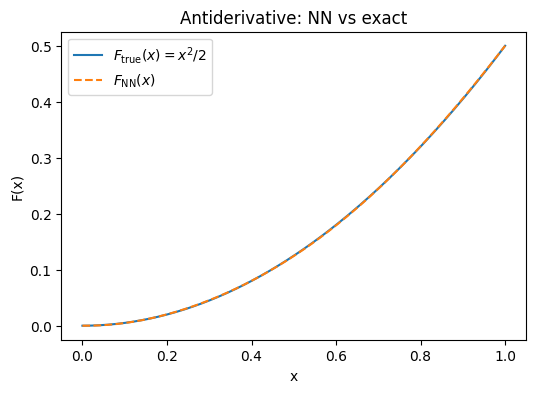

In [20]:
import matplotlib.pyplot as plt

x_plot = jnp.linspace(0, 1, 200)
F_nn = jax.vmap(F)(x_plot)
F_exact = jax.vmap(F_true)(x_plot)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_plot, F_exact, label=r"$F_{\mathrm{true}}(x) = x^2/2$")
ax.plot(x_plot, F_nn, "--", label=r"$F_{\mathrm{NN}}(x)$")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.legend()
ax.set_title("Antiderivative: NN vs exact")
plt.show()